In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
reviews_df = pd.read_csv("data/processed/reviews_summary.csv") #reviews table
aspects_df = pd.read_csv("data/processed/review_aspects.csv") #aspects table

In [3]:
print(reviews_df.shape)
print(aspects_df.shape)

(970, 19)
(2070, 4)


In [4]:
print(reviews_df.columns)
print(aspects_df.columns)

Index(['review_id', 'product_id', 'brand_name', 'product_title',
       'review_title', 'review_text', 'review_date', 'review_rating',
       'is_a_buyer', 'pro_user', 'review_label', 'mrp', 'price',
       'product_rating', 'product_rating_count', 'product_tags', 'product_url',
       'overall_sentiment', 'extraction_method'],
      dtype='str')
Index(['review_id', 'aspect', 'aspect_sentiment', 'issue'], dtype='str')


In [5]:
reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 970 entries, 0 to 969
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   review_id             970 non-null    int64  
 1   product_id            970 non-null    int64  
 2   brand_name            970 non-null    str    
 3   product_title         970 non-null    str    
 4   review_title          970 non-null    str    
 5   review_text           970 non-null    str    
 6   review_date           970 non-null    str    
 7   review_rating         970 non-null    float64
 8   is_a_buyer            970 non-null    bool   
 9   pro_user              970 non-null    bool   
 10  review_label          738 non-null    str    
 11  mrp                   970 non-null    int64  
 12  price                 970 non-null    int64  
 13  product_rating        970 non-null    float64
 14  product_rating_count  970 non-null    int64  
 15  product_tags          290 non-null

In [6]:
aspects_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2070 entries, 0 to 2069
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   review_id         2070 non-null   int64
 1   aspect            2070 non-null   str  
 2   aspect_sentiment  2070 non-null   str  
 3   issue             361 non-null    str  
dtypes: int64(1), str(3)
memory usage: 111.5 KB


In [7]:
reviews_df.isnull().sum()

review_id                 0
product_id                0
brand_name                0
product_title             0
review_title              0
review_text               0
review_date               0
review_rating             0
is_a_buyer                0
pro_user                  0
review_label            232
mrp                       0
price                     0
product_rating            0
product_rating_count      0
product_tags            680
product_url               0
overall_sentiment         0
extraction_method         0
dtype: int64

In [8]:
aspects_df.isnull().sum()

review_id              0
aspect                 0
aspect_sentiment       0
issue               1709
dtype: int64

In [9]:
reviews_df.describe()

,review_id,product_id,review_rating,mrp,price,product_rating,product_rating_count
count,9.700000e+02,9.700000e+02,970.000000,970.000000,970.000000,970.000000,970.000000
mean,1.468696e+07,9.313420e+05,4.378351,635.560825,518.808247,4.186082,4659.103093
std,7.524255e+06,1.480618e+06,1.100776,293.165730,239.419237,0.218263,4515.015033
min,2.403100e+04,2.500000e+02,1.000000,75.000000,75.000000,3.500000,6.000000
25%,1.064509e+07,7.300800e+04,4.000000,449.000000,350.000000,4.100000,1497.000000
50%,1.514642e+07,4.565590e+05,5.000000,600.000000,475.000000,4.100000,2857.000000
75%,2.005188e+07,8.343030e+05,5.000000,799.000000,665.000000,4.400000,6129.500000
max,2.961310e+07,6.028352e+06,5.000000,1798.000000,1725.000000,4.600000,22495.000000


In [10]:
reviews_df.duplicated().sum()

np.int64(0)

In [11]:
aspects_df.duplicated().sum()

np.int64(0)

In [12]:
reviews_df['brand_name'].value_counts()

brand_name
Kay Beauty                 337
Lakme                      171
Maybelline New York        167
Herbal Essences            152
L'Oreal Paris              105
NYX Professional Makeup     38
Name: count, dtype: int64

In [13]:
reviews_df['review_rating'].value_counts()

review_rating
5.0    648
4.0    178
3.0     62
1.0     55
2.0     27
Name: count, dtype: int64

In [14]:
reviews_df['product_rating_count'].value_counts()

product_rating_count
2077     28
14815    28
4619     26
2732     25
2857     23
         ..
65        1
6         1
11151     1
95        1
446       1
Name: count, Length: 88, dtype: int64

In [15]:
reviews_df['overall_sentiment'].value_counts()

overall_sentiment
positive    733
mixed       123
negative    104
neutral      10
Name: count, dtype: int64

In [16]:
reviews_df['product_tags'].value_counts()

product_tags
BESTSELLER              130
FEATURED, BESTSELLER    130
FEATURED                 30
Name: count, dtype: int64

In [17]:
aspects_df['aspect'].value_counts()

aspect
shade_match      272
finish           195
effectiveness    175
application      175
pigmentation     159
price_value      157
texture          155
longevity        148
quality          114
hair_effect      113
formula          104
fragrance         73
skin_feel         59
coverage          56
packaging         46
quantity          40
scalp_effect      13
blendability       6
performance        3
ingredients        2
delivery           2
manageability      1
weight             1
shade_range        1
Name: count, dtype: int64

In [18]:
aspects_df['aspect_sentiment'].value_counts()

aspect_sentiment
positive    1673
negative     347
neutral       49
mixed          1
Name: count, dtype: int64

Review Rating Distribution chart

Visualizing the count of reviews for each star rating (1 to 5)

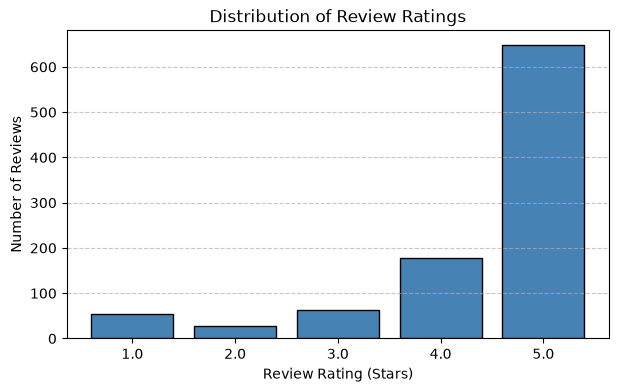

In [19]:
rating_counts = reviews_df['review_rating'].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(rating_counts.index.astype(str), rating_counts.values, color='steelblue', edgecolor='black')
plt.title('Distribution of Review Ratings')
plt.xlabel('Review Rating (Stars)')
plt.ylabel('Number of Reviews')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Observation: Ratings are heavily concentrated at 5 stars (648 reviews, ~67% of the sample), followed by 4 stars (178 reviews). Lower ratings (1 to 3 stars) represent a much smaller share of the dataset.

Number of Reviews by Brand

Comparing the total review counts across the beauty brands present in the sample.

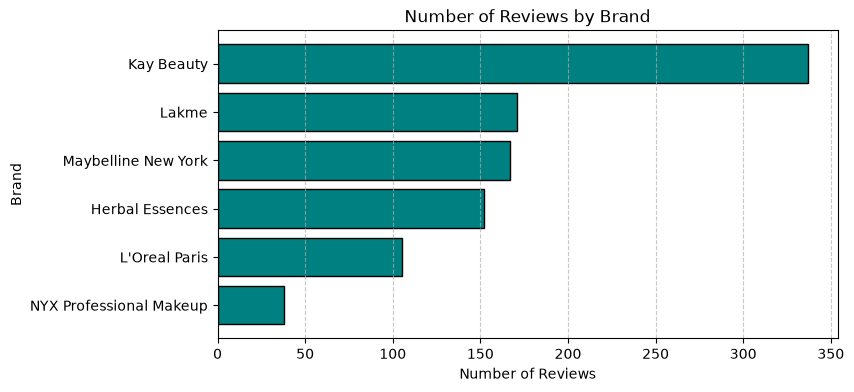

In [20]:
brand_counts = reviews_df['brand_name'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(brand_counts.index, brand_counts.values, color='teal', edgecolor='black')
plt.title('Number of Reviews by Brand')
plt.xlabel('Number of Reviews')
plt.ylabel('Brand')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Observation: Brand representation varies in the sample. Kay Beauty has the highest volume (337 reviews), followed by Lakme (171), Maybelline New York (167), Herbal Essences (152), and L'Oreal Paris (105). NYX Professional Makeup has the lowest representation with 38 reviews.

Product Price Distribution

Examining the spread of product prices across reviewed items.

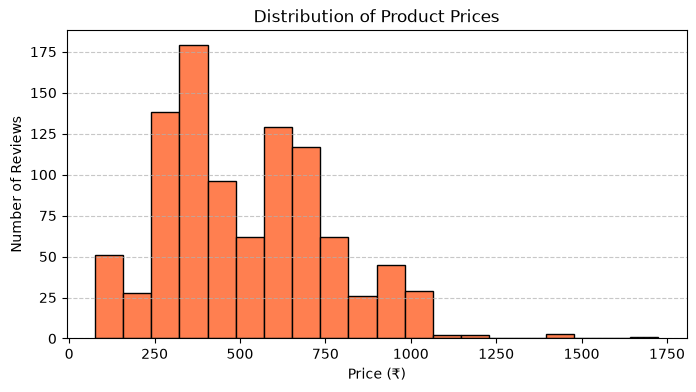

In [21]:
plt.figure(figsize=(8, 4))
plt.hist(reviews_df['price'], bins=20, color='coral', edgecolor='black')
plt.title('Distribution of Product Prices')
plt.xlabel('Price (₹)')
plt.ylabel('Number of Reviews')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Observation: Most reviewed products fall into the budget and mid-tier price range between ₹200 and ₹600, with a smaller number of higher-priced products extending up to ₹1,725.

Review Activity Over Time

Converting review_date to datetime, calculating yearly review counts first, and visualizing review volume by year.

In [22]:
reviews_df['review_year'] = pd.to_datetime(reviews_df['review_date']).dt.year
yearly_counts = reviews_df['review_year'].value_counts().sort_index()
yearly_counts

review_year
2014      2
2015      4
2016     10
2017     25
2018     80
2019    176
2020    261
2021    264
2022    148
Name: count, dtype: int64

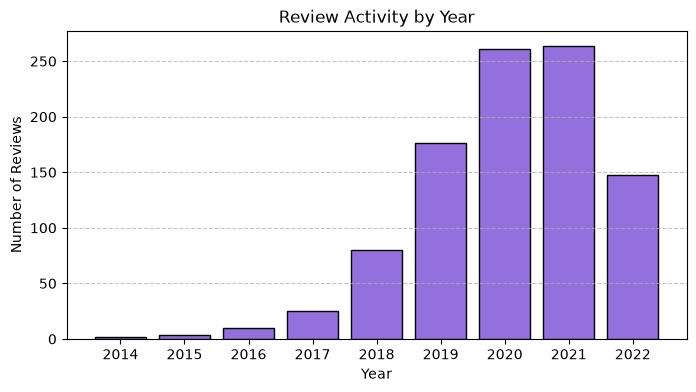

In [23]:
plt.figure(figsize=(8, 4))
plt.bar(yearly_counts.index.astype(str), yearly_counts.values, color='mediumpurple', edgecolor='black')
plt.title('Review Activity by Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Observation: The reviews span from 2014 to 2022. Activity was minimal from 2014 to 2016 (under 15 reviews per year), grew steadily between 2017 and 2019, peaked during 2020 and 2021 (with over 260 reviews each year), and dropped to 148 reviews in 2022.

## Summary of EDA Findings

### 1. Data Integrity & Completeness

- **Dimensions:** The processed dataset contains **970 reviews across 19 attributes** and **2,070 aspect-level records across 4 attributes**.
- **Duplicates:** Both tables contain **0 duplicate records**.
- **Missing Values:** Core analytical fields such as review_text, review_rating, brand_name, price, overall_sentiment, and aspect are complete. Missing values are limited to optional fields:
  - review_label is missing in 232 reviews.
  - product_tags is missing in 680 reviews.
  - issue is missing in 1,709 aspect rows, which is expected because an issue description is only recorded when a specific problem is extracted for an aspect.

### 2. Rating & Sentiment Tendencies

- The average review rating is **4.38 out of 5**, with around **85% of reviews rated 4 or 5 stars**.
- Overall sentiment is also largely positive:
  - **75.6% positive** (733)
  - **12.7% mixed** (123)
  - **10.7% negative** (104)
  - **1.0% neutral** (10)
- **Key Takeaway:** The high concentration of positive reviews shows that aggregate sentiment alone is not enough to understand the specific problems mentioned by dissatisfied customers. Aspect-level analysis provides more detail about these issues.

### 3. Product & Pricing Overview

- **Catalog Ratings:** Product-level ratings average **4.19 out of 5**, ranging from **3.5 to 4.6**, while product_rating_count ranges from **6 to 22,495**.
- **Pricing:** Product prices range from **₹75 to ₹1,725**, with a mean of approximately **₹519** and a median of approximately **₹475**.

### 4. Aspect-Level Discussion Themes

- Across the **2,070 extracted aspect mentions**, the most frequently discussed aspects are:
  1. shade_match — 272 mentions
  2. finish — 195 mentions
  3. effectiveness — 175 mentions
  4. application — 175 mentions
  5. pigmentation — 159 mentions
  6. price_value — 157 mentions
  7. texture — 155 mentions
  8. longevity — 148 mentions
- At the aspect level, **1,673 mentions (~81%) are positive** and **347 mentions (~17%) are negative**.
- **Key Takeaway:** Negative aspect mentions, along with the issue field where available, help identify specific customer complaints and provide more detailed feedback for further analysis.